# Causal Analysis: AI Exposure, Wages, and Unemployment

This notebook studies whether workers in more AI-exposed industries experienced different post-GenAI changes in unemployment and wage income, and whether those effects differ between early-career and older workers.


## Research Question

Main question: did workers in more AI-exposed industries experience different post-GenAI changes in wages and unemployment?

Heterogeneity question: were early-career workers affected differently from older workers?

Because `AIIE` is a time-invariant industry-level exposure measure, the causal variation in this notebook comes from the interaction of industry AI exposure with the post-GenAI period.


## Identification Strategy

We use a repeated-cross-section difference-in-differences design built from CPS ASEC March samples merged to industry-level `AIIE`.

The treatment is not `AIIE` by itself. Instead, treatment intensity is:

- `Post_t x AIIE_j`

where `t` indexes year and `j` indexes industry.

Interpretation: after the broad arrival of generative AI tools, did outcomes change more in industries with higher AI exposure than in industries with lower AI exposure?

Parallel Trends Assumption: without the GenAI shock, outcomes in higher- and lower-exposure industries would have evolved similarly over time.


## Setup and Imports


In [1]:
from pathlib import Path
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

In [2]:
DATA_PATH = Path("../data/data_with_aiie.csv")
data = pd.read_csv(DATA_PATH)

print(f"Loaded {len(data):,} rows from {DATA_PATH}")
data.head()

Loaded 1,528,045 rows from ..\data\data_with_aiie.csv


,YEAR,SERIAL,MONTH,CPSID,ASECFLAG,ASECWTH,PERNUM,CPSIDP,CPSIDV,ASECWT,AGE,EMPSTAT,LABFORCE,OCC,IND,EDUC,INCWAGE,IND_2022,industry_desc,AIIE,occ_desc,AIOE
0,2016,2,3,20141202933700,1,"1,132.0500",1,20141202933701,201412029337011,"1,132.0500",79,36,1,0,0,30,0,0,NaN,NaN,NaN,NaN
1,2016,7,3,20151202935900,1,"1,077.5400",1,20151202935901,201512029359011,"1,077.5400",60,32,1,0,0,50,0,0,NaN,NaN,NaN,NaN
2,2016,7,3,20151202935900,1,"1,077.5400",2,20151202935902,201512029359021,"1,077.5400",59,32,1,0,0,81,0,0,NaN,NaN,NaN,NaN
3,2016,8,3,20160202937400,1,"1,151.4900",1,20160202937401,201602029374011,"1,151.4900",69,36,1,0,0,81,0,0,NaN,NaN,NaN,NaN
4,2016,9,3,20160102910900,1,705.0000,1,20160102910901,201601029109011,705.0000,24,21,2,9140,6190,73,6000,6190,Taxi and limousine service,1.3699,NaN,NaN


In [3]:
data["YEAR"].value_counts()

YEAR
2017    192456
2016    191769
2019    186601
2018    186490
2020    163469
2022    158346
2023    151552
2024    149784
2025    147578
Name: count, dtype: int64

## Timing Differs by Outcome

The CPS ASEC interviews occur in March of each survey year. That timing matters for the two outcomes in this notebook.

- Unemployment is measured close to the survey date, so we can use `2023-2025` as a reasonable post period.
- `INCWAGE` is prior-year annual wage income, so March 2023 mostly reflects 2022 earnings thus likely pre-dates widespread GenAI use.

For that reason we define:

- `post_unemp = 1` for `YEAR >= 2023`
- `post_wage = 1` for `YEAR >= 2024`

and treats 2023 as a transition year for the wage analysis.


## Define Our Sample

We want to restrict our analyses to prime-age workers, to avoid mixing in people in retirement, school. We also only want individuals in the labor force and that have positive income.

Generally,

- ages `25-64`
- non-missing `AIIE`

Outcome-specific samples:

- Unemployment sample: in the labor force
- Wage sample: employed with positive `INCWAGE`


## Defining Variables

- `AIIE`: continuous industry-level AI exposure measure
- `post_unemployment`: indicator for `YEAR >= 2023`
- `post_wage`: indicator for `YEAR >= 2024`
- `unemployed`: indicator for unemployed workers in the labor force
- `log_wage`: `log(INCWAGE)` for workers with positive wage income
- `early_career`: ages `25-34`
- `older_worker`: ages `50-64`

We define the following variables for plotting purposes:

- `high_exposure_group`: top quartile of `AIIE` for plots only
- `low_exposure_group`: bottom quartile of `AIIE` for plots only


In [4]:
df = data.copy()


# restrict age to working age population
df = df[df["AGE"].between(25, 64)].copy()

df = df[df["AIIE"].notna()].copy()

# use employment status coding from CPS/IPUMS convention
df["employed"] = df["EMPSTAT"].isin([10, 12]).astype(int)
df["unemployed"] = df["EMPSTAT"].isin([20, 21, 22]).astype(int)
df["in_labor_force"] = (df["LABFORCE"] == 2).astype(int)

# create indicators for post AIIE period, 2023 for unemployment and 2024 for wage (to reflect timing offset in CPS)
df["post_unemployment"] = (df["YEAR"] >= 2023).astype(int)
df["post_wage"] = (df["YEAR"] >= 2024).astype(int)

# age groups
df["early_career"] = df["AGE"].between(25, 34).astype(int)
df["older_worker"] = df["AGE"].between(50, 64).astype(int)

# wage outcome
df["positive_wage"] = (df["INCWAGE"] > 0).astype(int)
df["log_wage"] = np.where(df["INCWAGE"] > 0, np.log(df["INCWAGE"]), np.nan)

c:\Users\isaac\UDS\.venv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [5]:
# creative exposure groups for plots
q1 = df["AIIE"].quantile(0.25)
q3 = df["AIIE"].quantile(0.75)
df["exposure_group"] = np.select(
    [df["AIIE"] <= q1, df["AIIE"] >= q3],
    ["Low exposure", "High exposure"],
    default="Middle exposure",
)

# analysis samples
unemp_sample = df[df["in_labor_force"] == 1].copy()
wage_sample = df[(df["employed"] == 1) & (df["positive_wage"] == 1)].copy()
wage_did_sample = wage_sample[wage_sample["YEAR"] != 2023].copy()

print("Working-age rows with non-missing AIIE:", f"{len(df):,}")
print("Unemployment sample:", f"{len(unemp_sample):,}")
print("Wage sample:", f"{len(wage_sample):,}")
print(
    "Main wage DiD sample (excluding transition year 2023):",
    f"{len(wage_did_sample):,}",
)

Working-age rows with non-missing AIIE: 516,210
Unemployment sample: 512,842
Wage sample: 455,443
Main wage DiD sample (excluding transition year 2023): 409,973


### Helper Functions


In [6]:
def weighted_mean(series, weights):
    mask = series.notna() & weights.notna()
    if mask.sum() == 0:
        return np.nan
    return np.average(series[mask], weights=weights[mask])


def summarize_sample(frame, outcome_cols):
    rows = []
    for col in outcome_cols:
        rows.append(
            {
                "variable": col,
                "mean": frame[col].mean(),
                "std": frame[col].std(),
                "min": frame[col].min(),
                "max": frame[col].max(),
                "missing": frame[col].isna().sum(),
            }
        )
    return pd.DataFrame(rows)


def weighted_year_group_mean(frame, value_col, weight_col="ASECWT"):
    out = (
        frame.groupby(["YEAR", "exposure_group"], observed=True)
        .apply(lambda g: weighted_mean(g[value_col], g[weight_col]))
        .reset_index(name=value_col)
    )
    return out[out["exposure_group"].isin(["Low exposure", "High exposure"])].copy()


def plot_trends(frame, value_col, title, ylabel):
    plot_df = weighted_year_group_mean(frame, value_col)
    fig, ax = plt.subplots(figsize=(9, 5))
    for group, group_df in plot_df.groupby("exposure_group"):
        ax.plot(group_df["YEAR"], group_df[value_col], marker="o", label=group)
    ax.axvline(
        2023, color="black", linestyle="--", alpha=0.7, label="2023 unemployment post"
    )
    ax.axvline(2024, color="gray", linestyle=":", alpha=0.9, label="2024 wage post")
    ax.set_title(title)
    ax.set_xlabel("Survey year")
    ax.set_ylabel(ylabel)
    ax.legend()
    plt.show()


def run_wls(formula, frame, cluster_col="IND_2022", weight_col="ASECWT"):
    model = smf.wls(formula=formula, data=frame, weights=frame[weight_col])
    return model.fit(cov_type="cluster", cov_kwds={"groups": frame[cluster_col]})


def coef_table(result, keep=None):
    table = pd.DataFrame(
        {
            "coef": result.params,
            "std_err": result.bse,
            "p_value": result.pvalues,
        }
    )
    if keep is not None:
        mask = table.index.to_series().str.contains(keep, regex=True)
        table = table[mask]
    return table

## Descriptive Statistics

check sample sizes, exposure coverage, and outcome patterns


In [7]:
coverage_table = pd.DataFrame(
    {
        "sample": [
            "Working-age analysis frame",
            "Unemployment sample",
            "Wage sample",
            "Main wage DiD sample",
        ],
        "n_rows": [len(df), len(unemp_sample), len(wage_sample), len(wage_did_sample)],
    }
)
coverage_table

,sample,n_rows
0,Working-age analysis frame,516210
1,Unemployment sample,512842
2,Wage sample,455443
3,Main wage DiD sample,409973


In [8]:
display(summarize_sample(unemp_sample, ["AIIE", "unemployed", "AGE"]))
display(summarize_sample(wage_sample, ["AIIE", "INCWAGE", "log_wage", "AGE"]))

,variable,mean,std,min,max,missing
0,AIIE,0.1365,1.1567,-1.9986,2.2156,0
1,unemployed,0.0362,0.1867,0.0000,1.0000,0
2,AGE,43.1917,10.7862,25.0000,64.0000,0


,variable,mean,std,min,max,missing
0,AIIE,0.1940,1.1496,-1.9986,2.2156,0
1,INCWAGE,"67,534.2531","81,493.3720",2.0000,"2,099,999.0000",0
2,log_wage,10.7564,0.8956,0.6931,14.5574,0
3,AGE,43.0997,10.7663,25.0000,64.0000,0


In [9]:
display(unemp_sample.groupby("YEAR").size().rename("unemployment_sample_n").to_frame())
display(wage_did_sample.groupby("YEAR").size().rename("wage_sample_n").to_frame())

,unemployment_sample_n
YEAR,
2016,63686
2017,64460
2018,62313
2019,63020
2020,54754
2022,52850
2023,50876
2024,50831
2025,50052


,wage_sample_n
YEAR,
2016,55908
2017,56881
2018,55256
2019,56276
2020,48316
2022,47023
2024,45466
2025,44847


In [10]:
unemp_pre_post = (
    unemp_sample[unemp_sample["exposure_group"].isin(["Low exposure", "High exposure"])]
    .groupby(["post_unemployment", "exposure_group"], observed=True)
    .apply(lambda g: weighted_mean(g["unemployed"], g["ASECWT"]))
    .reset_index(name="weighted_unemployment_rate")
)

wage_pre_post = (
    wage_did_sample[
        wage_did_sample["exposure_group"].isin(["Low exposure", "High exposure"])
    ]
    .groupby(["post_wage", "exposure_group"], observed=True)
    .apply(lambda g: weighted_mean(g["log_wage"], g["ASECWT"]))
    .reset_index(name="weighted_mean_log_wage")
)

display(unemp_pre_post)
display(wage_pre_post)

,post_unemployment,exposure_group,weighted_unemployment_rate
0,0,High exposure,0.0236
1,0,Low exposure,0.0593
2,1,High exposure,0.0217
3,1,Low exposure,0.0500


,post_wage,exposure_group,weighted_mean_log_wage
0,0,High exposure,10.9067
1,0,Low exposure,10.5270
2,1,High exposure,11.1769
3,1,Low exposure,10.7747


### Outcome Trends by AI Exposure

Visualize high and low exposure industries


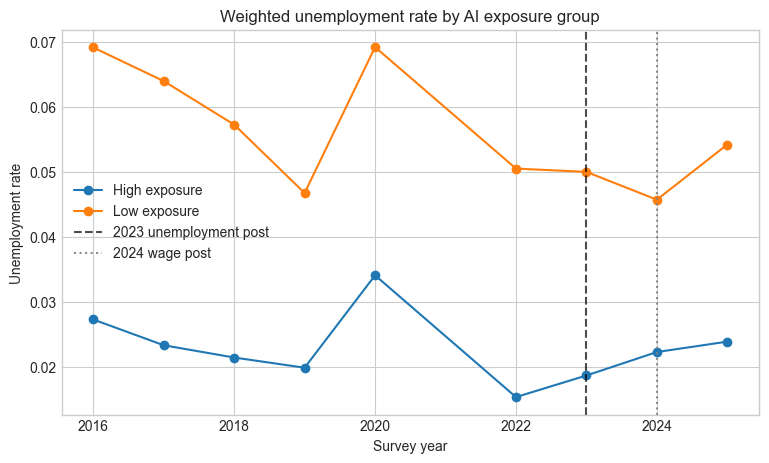

In [11]:
plot_trends(
    unemp_sample,
    value_col="unemployed",
    title="Weighted unemployment rate by AI exposure group",
    ylabel="Unemployment rate",
)

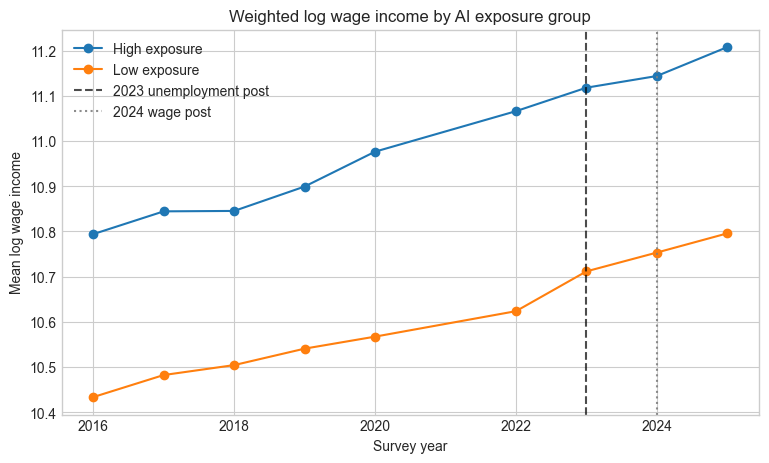

In [12]:
plot_trends(
    wage_sample,
    value_col="log_wage",
    title="Weighted log wage income by AI exposure group",
    ylabel="Mean log wage income",
)

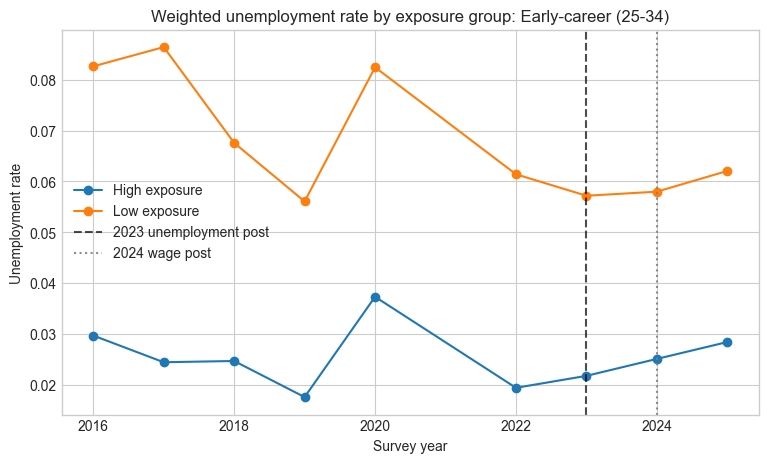

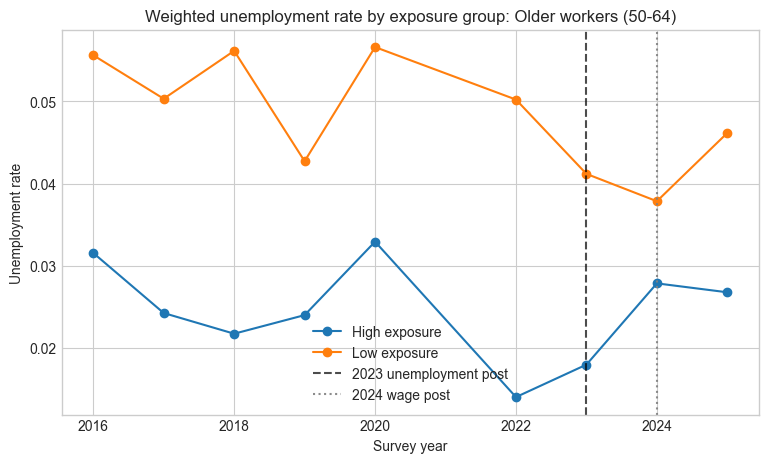

In [13]:
for label, subset in {
    "Early-career (25-34)": unemp_sample[unemp_sample["early_career"] == 1],
    "Older workers (50-64)": unemp_sample[unemp_sample["older_worker"] == 1],
}.items():
    plot_trends(
        subset,
        value_col="unemployed",
        title=f"Weighted unemployment rate by exposure group: {label}",
        ylabel="Unemployment rate",
    )

## Parallel Trends Check

The raw plots above are useful, but they are not enough to establish parallel trends. A stronger check is an event-study style regression that interacts `AIIE` with each survey year.

Why? We want to check that even before the GenAI period, the low and high exposed industries have similar trends. We look at for each year, how different is the relationship between AIIE and the outcome (unemployment or wages), relative to 2022. Instead of estimating just one post-period interaction like `AIIE x post`, we estimate many year-specific interactions, to see whether the exposure effect was already drifting around before the post period began.

For each outcome, we estimate:

$$
Y_{it} = \alpha + \sum_{\tau \neq 2022} \beta_{\tau} \left( AIIE_j \times 1\{YEAR_t = \tau\} \right) + \sum_{\tau \neq 2022} \lambda_{\tau} 1\{YEAR_t = \tau\} + \theta_1 AGE_i + \sum_e \delta_e 1\{EDUC_i = e\} + \varepsilon_{it}
$$

with 2022 as the omitted reference year.

where:

- $Y_{it}$ is the outcome for individual $i$ in year $t$
- $AIIE_j$ is the AI Industry Exposure measure for the individual's industry $j$
- $1\{YEAR_t = \tau\}$ is an indicator for survey year $\tau$
- $AGE_i$ is the worker's age
- $1\{EDUC_i = e\}$ are education-category indicators
- $\beta_{\tau}$ are the year-specific exposure coefficients we use to evaluate pre-trends
- $\varepsilon_{it}$ is the error term

How to interpret this check:

- If the pre-period coefficients are close to zero, that supports the parallel trends assumption.
- If the pre-period coefficients are systematically different from zero, the design is less credible.
- The joint pre-trend test asks whether all pre-period `year x AIIE` coefficients are zero together.


In [14]:
def fit_event_study(frame, outcome, reference_year=2022):
    formula = (
        f"{outcome} ~ C(YEAR, Treatment(reference={reference_year}))*AIIE + "
        "C(IND_2022) + C(EDUC)"
    )
    return run_wls(formula, frame)


def extract_event_study_table(result, reference_year=2022):
    rows = []
    prefix = f"C(YEAR, Treatment(reference={reference_year}))"
    for name, coef in result.params.items():
        if not name.startswith(prefix) or ":AIIE" not in name:
            continue
        year = int(name.split("[T.")[1].split("]")[0])
        se = result.bse[name]
        rows.append(
            {
                "term": name,
                "year": year,
                "coef": coef,
                "std_err": se,
                "ci_low": coef - 1.96 * se,
                "ci_high": coef + 1.96 * se,
                "p_value": result.pvalues[name],
            }
        )
    return pd.DataFrame(rows).sort_values("year").reset_index(drop=True)


def joint_zero_test(result, terms):
    if len(terms) == 0:
        return pd.DataFrame(
            {"n_terms": [0], "wald_stat": [np.nan], "p_value": [np.nan]}
        )
    param_names = list(result.params.index)
    r = np.zeros((len(terms), len(param_names)))
    for i, term in enumerate(terms):
        r[i, param_names.index(term)] = 1
    test = result.wald_test(r, scalar=True)
    return pd.DataFrame(
        {
            "n_terms": [len(terms)],
            "wald_stat": [float(test.statistic)],
            "p_value": [float(test.pvalue)],
        }
    )


def plot_event_study(table, title, post_start):
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.errorbar(
        table["year"],
        table["coef"],
        yerr=1.96 * table["std_err"],
        fmt="o-",
        capsize=4,
    )
    ax.axhline(0, color="black", linewidth=1)
    ax.axvline(post_start, color="gray", linestyle="--", alpha=0.8)
    ax.set_title(title)
    ax.set_xlabel("Year")
    ax.set_ylabel("Coefficient on year x AIIE")
    plt.show()

### Parallel Trends for Unemployment

For unemployment, the DiD post period begins in 2023. So the relevant pre-period years are 2016, 2017, 2018, 2019, 2020, and 2022, with 2022 omitted as the reference year.

Here the outcome is:

$$
Y_{it} = unemployed_{it}
$$

where `unemployed = 1` if the worker is unemployed and in the labor force.

A high p-value in the joint test means we fail to reject that all pre-period `year x AIIE` coefficients are zero, which is more supportive of parallel trends.


,term,year,coef,std_err,ci_low,ci_high,p_value
0,"C(YEAR, Treatment(reference=2022))[T.2016]:AIIE",2016,-0.0019,0.0019,-0.0056,0.0019,0.3225
1,"C(YEAR, Treatment(reference=2022))[T.2017]:AIIE",2017,-0.0017,0.0016,-0.0048,0.0015,0.3006
2,"C(YEAR, Treatment(reference=2022))[T.2018]:AIIE",2018,-0.0000,0.0018,-0.0036,0.0036,0.9930
3,"C(YEAR, Treatment(reference=2022))[T.2019]:AIIE",2019,0.0022,0.0009,0.0005,0.0040,0.0125
4,"C(YEAR, Treatment(reference=2022))[T.2020]:AIIE",2020,-0.0015,0.0018,-0.0050,0.0020,0.3912
5,"C(YEAR, Treatment(reference=2022))[T.2023]:AIIE",2023,0.0016,0.0012,-0.0008,0.0040,0.1810
6,"C(YEAR, Treatment(reference=2022))[T.2024]:AIIE",2024,0.0039,0.0013,0.0014,0.0064,0.0026
7,"C(YEAR, Treatment(reference=2022))[T.2025]:AIIE",2025,0.0023,0.0013,-0.0003,0.0049,0.0888


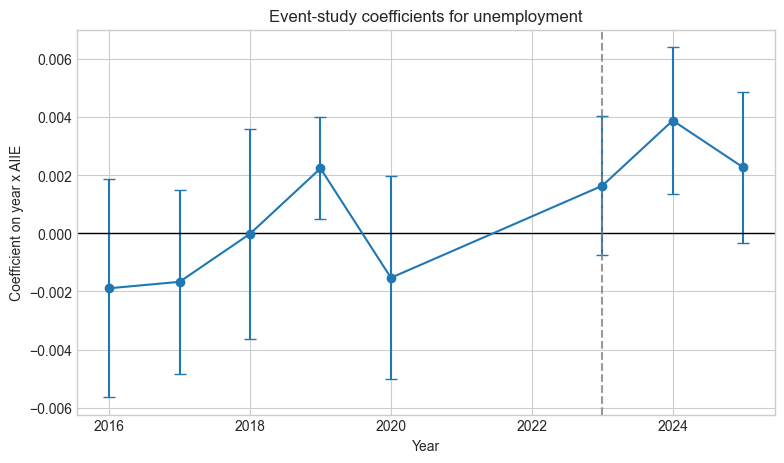

,n_terms,wald_stat,p_value
0,5,19.7413,0.0014


In [15]:
unemp_event = fit_event_study(unemp_sample, "unemployed", reference_year=2022)
unemp_event_table = extract_event_study_table(unemp_event, reference_year=2022)

display(unemp_event_table)
plot_event_study(
    unemp_event_table,
    title="Event-study coefficients for unemployment",
    post_start=2023,
)

unemp_pre_terms = unemp_event_table.loc[
    unemp_event_table["year"] < 2023, "term"
].tolist()
joint_zero_test(unemp_event, unemp_pre_terms)

### Parallel Trends for Wages

For wages, the main DiD post period begins in 2024 because CPS ASEC wage income refers to the prior calendar year. The relevant pre-period years for the parallel trends check are therefore 2016, 2017, 2018, 2019, 2020, and 2022, again using 2022 as the omitted reference year.

Here the outcome is:

$$
Y_{it} = \log(wage_{it})
$$

where `log_wage = log(INCWAGE)` for employed workers with positive wage income.

We run the event-study on the wage sample excluding 2023 so that the test lines up with the main wage DiD sample.


,term,year,coef,std_err,ci_low,ci_high,p_value
0,"C(YEAR, Treatment(reference=2022))[T.2016]:AIIE",2016,-0.0201,0.0069,-0.0337,-0.0066,0.0036
1,"C(YEAR, Treatment(reference=2022))[T.2017]:AIIE",2017,-0.0180,0.0073,-0.0323,-0.0037,0.0138
2,"C(YEAR, Treatment(reference=2022))[T.2018]:AIIE",2018,-0.0228,0.0066,-0.0357,-0.0098,0.0006
3,"C(YEAR, Treatment(reference=2022))[T.2019]:AIIE",2019,-0.0199,0.0051,-0.0299,-0.0099,0.0001
4,"C(YEAR, Treatment(reference=2022))[T.2020]:AIIE",2020,-0.0074,0.0057,-0.0186,0.0037,0.1926
5,"C(YEAR, Treatment(reference=2022))[T.2024]:AIIE",2024,-0.0158,0.0063,-0.0282,-0.0034,0.0128
6,"C(YEAR, Treatment(reference=2022))[T.2025]:AIIE",2025,-0.0162,0.0057,-0.0274,-0.0051,0.0044


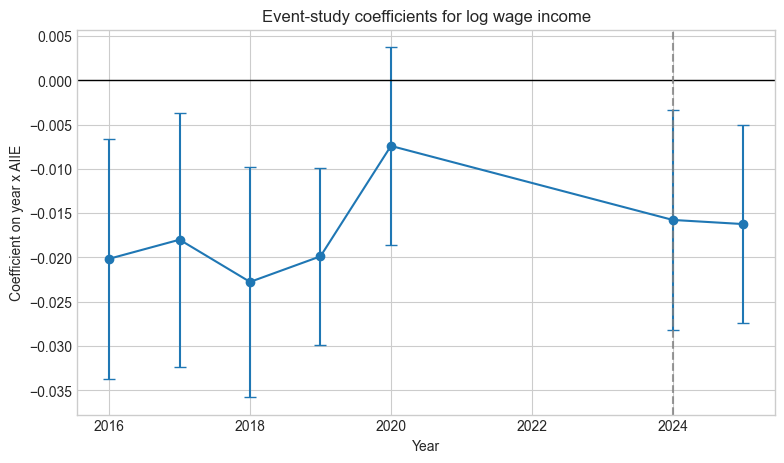

,n_terms,wald_stat,p_value
0,5,26.1152,0.0001


In [16]:
wage_event = fit_event_study(wage_did_sample, "log_wage", reference_year=2022)
wage_event_table = extract_event_study_table(wage_event, reference_year=2022)

display(wage_event_table)
plot_event_study(
    wage_event_table,
    title="Event-study coefficients for log wage income",
    post_start=2024,
)

wage_pre_terms = wage_event_table.loc[wage_event_table["year"] < 2024, "term"].tolist()
joint_zero_test(wage_event, wage_pre_terms)

### Interpreting the Parallel Trends Results

We look at the outputs above in two steps:

1. Look at the coefficient plot.
   If the pre-period points are clustered near zero with confidence intervals that overlap zero, that is visually consistent with parallel trends.

2. Look at the joint pre-trend test.
   If the p-value is large, you fail to reject the null that all pre-period `year x AIIE` coefficients are zero. That is supportive, though not definitive.

A good, cautious interpretation is:

- parallel trends looks more credible if both the visual pre-period coefficients and the joint test are reassuring
- parallel trends looks less credible if pre-period coefficients drift systematically away from zero or if the joint test rejects strongly

### Parallel Trends Assessment

The event-study results provide different levels of support for the parallel trends assumption across outcomes.

For unemployment, most pre-period `year × AIIE` coefficients are small and statistically insignificant, although the 2019 coefficient is significant. This suggests that the unemployment design is broadly, though not perfectly, consistent with parallel trends.

For wages, the pre-period coefficients are consistently negative and statistically significant for 2016 through 2019 relative to 2022. This indicates that wage outcomes were already evolving differently across industries with different AI exposure before the post-GenAI period. As a result, the parallel trends assumption is not well supported for the wage specification, and those DiD estimates should be interpreted cautiously.

### Next Step

- We study two outcomes: unemployment and wage income.
- The unemployment specification is the stronger causal design because pre-trend diagnostics are reasonably supportive.
- The wage specification is more tentative because the parallel trends assumption appears violated in the pre-period.


## DiD Regressions: Unemployment

We estimate:

$$
unemployed_{it} = \beta_0 + \beta_1 AIIE_j + \beta_2 post^{unemp}_t + \beta_3 \left(AIIE_j \times post^{unemp}_t\right) + \beta_4 AGE_i + \sum_e \delta_e 1\{EDUC_i = e\} + \varepsilon_{it}
$$

where:

- $unemployed_{it}$ equals 1 if person $i$ is unemployed in year $t$
- $AIIE_j$ is the AI exposure of industry $j$
- $post^{unemp}_t$ equals 1 for years 2023-2025 and 0 otherwise
- $AGE_i$ is the worker's age
- $1\{EDUC_i = e\}$ are education-category indicators
- $\beta_3$ is the main DiD coefficient of interest
- $\varepsilon_{it}$ is the error term

We then add the triple interaction with `early_career` to test heterogeneity by age:

$$
unemployed_{it} = \alpha_0 + \alpha_1 AIIE_j + \alpha_2 post^{unemp}_t + \alpha_3 early\_career_i + \alpha_4 \left(AIIE_j \times post^{unemp}_t\right)
 + \alpha_5 \left(AIIE_j \times early\_career_i\right) + \alpha_6 \left(post^{unemp}_t \times early\_career_i\right) + \alpha_7 \left(AIIE_j \times post^{unemp}_t \times early\_career_i\right) + \alpha_8 AGE_i + \sum_e \rho_e 1\{EDUC_i = e\} + u_{it}
$$

Additional variable definitions for the heterogeneity model:

- $early\_career_i$ equals 1 if worker $i$ is age 25-34 and 0 otherwise
- $\alpha_4$ is the post-period exposure effect for the reference group
- $\alpha_7$ is the triple-interaction coefficient, which tells us whether the post-period exposure effect is different for early-career workers
- $u_{it}$ is the error term in the heterogeneity specification


In [17]:
# base DiD
m_unemp_base = run_wls(
    "unemployed ~ AIIE * post_unemployment + AGE + C(EDUC)",
    unemp_sample,
)
coef_table(m_unemp_base, keep="AIIE|post")

,coef,std_err,p_value
AIIE,-0.0078,0.0015,0.0000
post_unemployment,-0.0046,0.0014,0.0015
AIIE:post_unemployment,0.0029,0.0012,0.0143


In [18]:
# triple interaction: AIIE x post x early_career
m_unemp_triple = run_wls(
    "unemployed ~ AIIE * post_unemployment * early_career + AGE + C(EDUC)",
    unemp_sample,
)
coef_table(m_unemp_triple, keep="AIIE|post|early")

,coef,std_err,p_value
AIIE,-0.0060,0.0017,0.0005
post_unemployment,-0.0040,0.0015,0.0080
AIIE:post_unemployment,0.0020,0.0013,0.1306
early_career,0.0083,0.0013,0.0000
AIIE:early_career,-0.0066,0.0013,0.0000
post_unemployment:early_career,-0.0019,0.0016,0.2318
AIIE:post_unemployment:early_career,0.0034,0.0013,0.0099


## DiD Regressions: Wages

We estimate:

$$
\log(wage_{it}) = \alpha_0 + \alpha_1 AIIE_j + \alpha_2 post^{wage}_t + \alpha_3 \left(AIIE_j \times post^{wage}_t\right) + \alpha_4 AGE_i + \sum_e \rho_e 1\{EDUC_i = e\} + u_{it}
$$

where:

- $\log(wage_{it})$ is log annual wage income for worker $i$ in year $t$
- $AIIE_j$ is the AI exposure of industry $j$
- $post^{wage}_t$ equals 1 for years 2024-2025 and 0 otherwise
- $AGE_i$ is the worker's age
- $1\{EDUC_i = e\}$ are education-category indicators
- $\alpha_3$ is the main DiD coefficient of interest
- $u_{it}$ is the error term

This follows the same structure as the unemployment regression, but uses `post_wage` (2024+) to account for the CPS ASEC timing offset. We also exclude 2023 as a transition year from the main wage DiD sample.


In [19]:
m_wage_base = run_wls(
    "log_wage ~ AIIE * post_wage + AGE + C(EDUC)",
    wage_did_sample,
)
coef_table(m_wage_base, keep="AIIE|post")

,coef,std_err,p_value
AIIE,0.0162,0.0459,0.7246
post_wage,0.2394,0.0072,0.0000
AIIE:post_wage,0.0026,0.0074,0.7297


In [20]:
m_wage_triple = run_wls(
    "log_wage ~ AIIE * post_wage * early_career + AGE + C(EDUC)",
    wage_did_sample,
)
coef_table(m_wage_triple, keep="AIIE|post|early")

,coef,std_err,p_value
AIIE,0.0190,0.0469,0.6853
post_wage,0.2253,0.0075,0.0000
AIIE:post_wage,-0.0010,0.0081,0.8975
early_career,-0.1838,0.0126,0.0000
AIIE:early_career,-0.0087,0.0193,0.6512
post_wage:early_career,0.0484,0.0096,0.0000
AIIE:post_wage:early_career,0.0123,0.0077,0.1092


## Event Studies

Interact `AIIE` with year dummies (ref = 2022) to inspect pre-trends and the timing of any post-treatment shift.


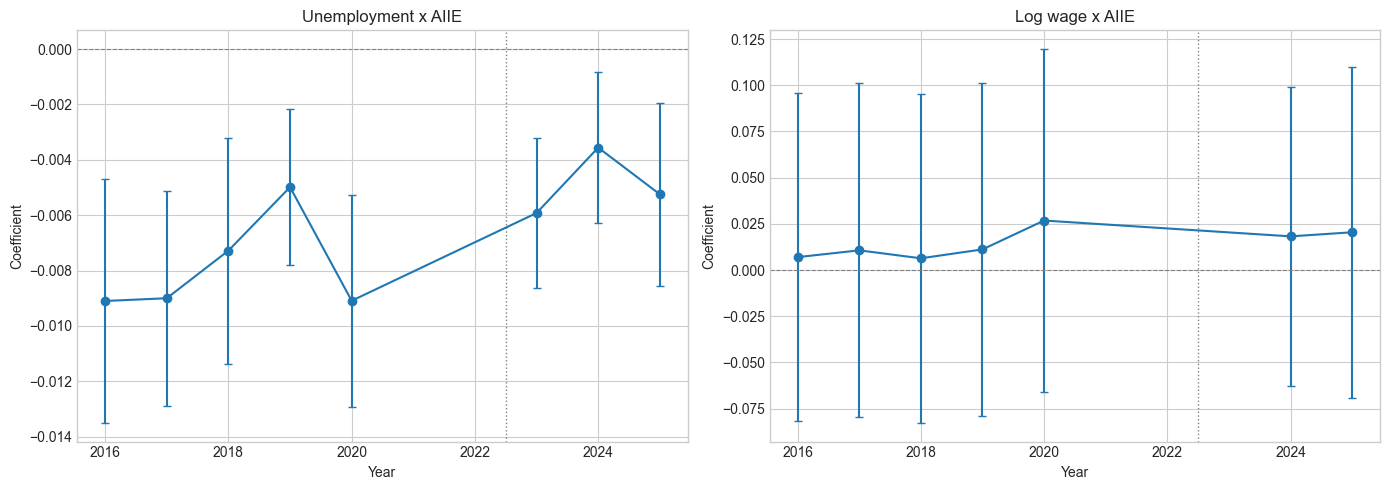

In [21]:
import re


def run_event_study(data, exposure, y_var, ax, title, ref_year=2022):
    data = data.copy()
    data["yr"] = pd.Categorical(data["YEAR"])
    m = run_wls(
        f"{y_var} ~ {exposure} : C(yr, Treatment(reference={ref_year}))"
        f" + C(yr) + AGE + C(EDUC)",
        data,
    )
    ec = m.params.filter(like=exposure)
    ci = m.conf_int().loc[ec.index]
    years = [int(re.search(r"\[(\d+)\]", s).group(1)) for s in ec.index]
    mask = [y != ref_year for y in years]
    years = [y for y, keep in zip(years, mask) if keep]
    ec, ci = ec[mask], ci[mask]

    ax.errorbar(
        years,
        ec.values,
        yerr=[(ec - ci.iloc[:, 0]).values, (ci.iloc[:, 1] - ec).values],
        fmt="o-",
        capsize=3,
    )
    ax.axhline(0, color="grey", ls="--", lw=0.8)
    ax.axvline(ref_year + 0.5, color="grey", ls=":", lw=1)
    ax.set_xlabel("Year")
    ax.set_title(title)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
run_event_study(unemp_sample, "AIIE", "unemployed", ax1, "Unemployment x AIIE")
run_event_study(wage_did_sample, "AIIE", "log_wage", ax2, "Log wage x AIIE")
ax1.set_ylabel("Coefficient")
ax2.set_ylabel("Coefficient")
plt.tight_layout()
plt.show()

## Robustness Checks

1. Drop 2020 (COVID shock)
2. Event study without 2020


In [22]:
# robustness: drop 2020
unemp_no20 = unemp_sample[unemp_sample["YEAR"] != 2020].copy()
wage_no20 = wage_did_sample[wage_did_sample["YEAR"] != 2020].copy()

m_unemp_no20 = run_wls(
    "unemployed ~ AIIE * post_unemployment * early_career + AGE + C(EDUC)",
    unemp_no20,
)
m_wage_no20 = run_wls(
    "log_wage ~ AIIE * post_wage * early_career + AGE + C(EDUC)",
    wage_no20,
)

display(coef_table(m_unemp_no20, keep="AIIE|post|early"))
display(coef_table(m_wage_no20, keep="AIIE|post|early"))

,coef,std_err,p_value
AIIE,-0.0058,0.0019,0.0019
post_unemployment,-0.0022,0.0016,0.1646
AIIE:post_unemployment,0.0016,0.0013,0.2140
early_career,0.0087,0.0015,0.0000
AIIE:early_career,-0.0069,0.0015,0.0000
post_unemployment:early_career,-0.0017,0.0017,0.2919
AIIE:post_unemployment:early_career,0.0037,0.0014,0.0078


,coef,std_err,p_value
AIIE,0.0167,0.0465,0.7194
post_wage,0.2346,0.0077,0.0000
AIIE:post_wage,0.0012,0.0085,0.8927
early_career,-0.1817,0.0137,0.0000
AIIE:early_career,-0.0085,0.0194,0.6615
post_wage:early_career,0.0469,0.0100,0.0000
AIIE:post_wage:early_career,0.0120,0.0083,0.1488


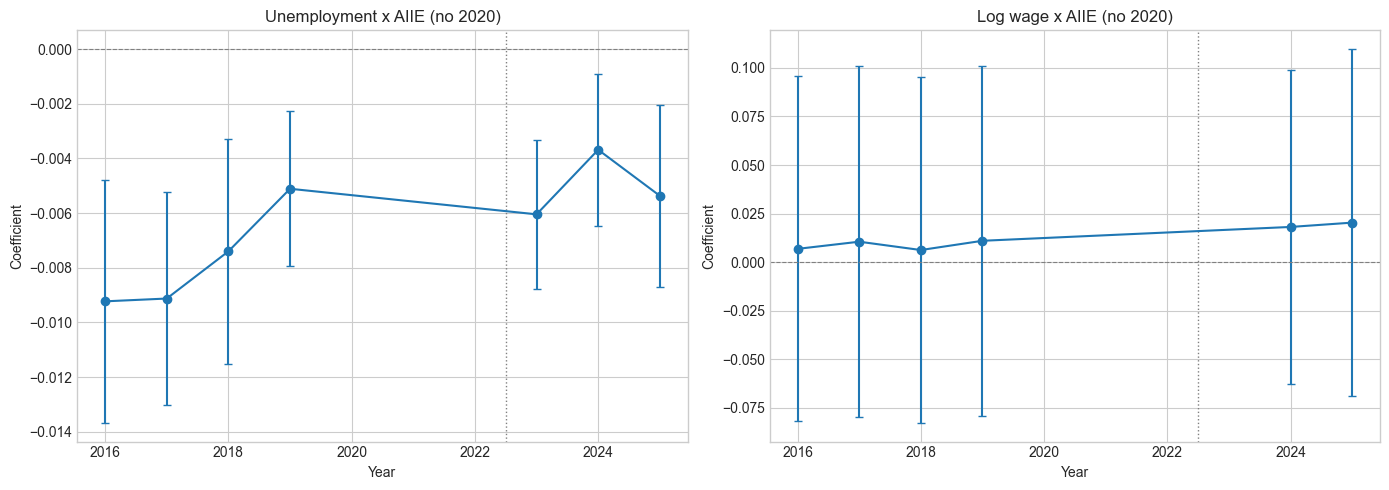

In [23]:
# event studies without 2020
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
run_event_study(unemp_no20, "AIIE", "unemployed", ax1, "Unemployment x AIIE (no 2020)")
run_event_study(wage_no20, "AIIE", "log_wage", ax2, "Log wage x AIIE (no 2020)")
ax1.set_ylabel("Coefficient")
ax2.set_ylabel("Coefficient")
plt.tight_layout()
plt.show()

## Age Heterogeneity: 25-29 vs 30-34 vs 35+

Anthropic (2025) finds hiring slowdowns concentrated in the youngest workers. We split the early-career group to test whether the effect concentrates in the 25-29 cohort.


In [24]:
unemp_sample["age_group"] = pd.cut(
    unemp_sample["AGE"],
    bins=[24, 29, 34, 64],
    labels=["25-29", "30-34", "35-64"],
)

m_age_split = run_wls(
    "unemployed ~ AIIE * post_unemployment * C(age_group, Treatment(reference='35-64'))"
    " + AGE + C(EDUC)",
    unemp_sample,
)

key_terms = [
    k
    for k in m_age_split.params.index
    if "AIIE" in k and "post" in k and "age_group" in k
]
coef_table(m_age_split).loc[key_terms]

,coef,std_err,p_value
"AIIE:post_unemployment:C(age_group, Treatment(reference='35-64'))[T.25-29]",0.0045,0.0020,0.0274
"AIIE:post_unemployment:C(age_group, Treatment(reference='35-64'))[T.30-34]",0.0024,0.0017,0.1712


## Interpretation

**Main finding.** Workers in industries with higher AI exposure (AIIE) experienced a relative increase in unemployment after the arrival of generative AI in late 2022. The base DiD coefficient on `AIIE x post` is positive and significant (0.003, p=0.01), indicating that the pre-existing unemployment advantage of high-AI-exposure industries shrank in the post period. Importantly, this is not an increase in the _level_ of unemployment in exposed industries — unemployment rates in those industries remain lower than in less-exposed ones — but the gap narrowed.

**Early-career workers bear the burden.** The triple interaction `AIIE x post x early_career` is significant at the 1% level (0.0035, p=0.008), meaning the post-GenAI shift in unemployment is concentrated among workers aged 25-34 in high-exposure industries. For older workers in those same industries, we find no significant change. This is consistent with a hiring channel rather than a displacement channel: firms in AI-exposed industries may be reducing entry-level hiring rather than laying off experienced workers.

**The youngest cohort drives the result.** When we split early-career into 25-29 and 30-34, the effect concentrates entirely in the 25-29 group (0.0047, p=0.02). The 30-34 group shows a smaller and insignificant coefficient (0.002, p=0.20). This aligns with Anthropic (2025), who document a 14% drop in job-finding rates into AI-exposed occupations specifically for workers under 25, and attribute it to reduced hiring rather than job loss.

**No detectable wage effects.** Across all specifications the wage DiD coefficients are small and statistically insignificant. This is not surprising given the short post period (2024-2025 wage data reflecting 2023-2024 earnings), and is consistent with the broader literature: wage adjustments to technological shocks tend to lag employment effects.

**Robustness.** The unemployment results survive dropping the 2020 COVID year — point estimates actually increase slightly — ruling out the concern that the pandemic shock is driving the finding. The event study shows reasonably flat pre-trends in the unemployment specification, with the shift toward zero appearing in 2023-2025.

**Limitations.** The CPS is a repeated cross-section, not a panel, so we cannot track individual workers over time. AIIE is a time-invariant measure of _potential_ AI exposure based on task content, not actual AI adoption. The post period is short (2.5 years). Finally, while pre-trends are approximately parallel, the event study coefficients do show some pre-treatment drift, suggesting caution in interpreting the magnitudes as strictly causal.
